# Analiza Intenției de Cumpărare Online prin Arbori de Decizie


## Descrierea Proiectului

Acest proiect aplică tehnici de **clasificare bazate pe arbori de decizie** pentru a analiza și prezice intenția de cumpărare a vizitatorilor unui site de e-commerce. Folosind datele de sesiune ale utilizatorilor, modelele construite identifică **pattern-uri comportamentale** care diferențiază vizitatorii care finalizează o achiziție de cei care nu o fac.

## Obiectiv

Variabila țintă este **`Revenue`** (calitativă, binară: `TRUE` / `FALSE`), care indică dacă o sesiune de navigare s-a finalizat cu o tranzacție comercială.

Scopul principal este construirea unor modele predictive capabile să clasifice corect intenția de cumpărare pe baza caracteristicilor comportamentale și tehnice ale sesiunii.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
os.getcwd()

'/home/matei/Financial-Fraud-Detection/notebooks/OnlinePurchasing'

In [3]:
path_to_dataset = '../../data/raw/online_shoppers_intention_recoded.csv'

if not os.path.isfile(path_to_dataset):
    print("no good")
else:
    df = pd.read_csv(path_to_dataset)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  str    
 12  Browser                  12330 non-null  str    
 13  Region                   12330 non-null  str    
 14  TrafficType              12330 no

In [6]:
df.shape

(12330, 18)

-   Dimensiune: 12.330 înregistrări (linii), 18 variabile(coloane)

-   Sursă: UCI Machine Learning Repository / Kaggle.

-   Perioadă: Date colectate pe parcursul unui an pentru a evita bias-ul de sezonalitate (deși lipsesc Ianuarie și Aprilie).

## EDA

-   Valori lipsa

-   Valori unice

In [7]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              5
Browser                       9
Region                        9
TrafficType                  12
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [8]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

-   Duplicate

In [9]:
df.duplicated().sum()

np.int64(125)

In [10]:
df.shape[0]

12330

In [12]:
df = df.drop_duplicates()
df.shape[0]

12205

In [13]:

print(f"VisitorType valori: {df['VisitorType'].unique()}")
print(f"Weekend valori: {df['Weekend'].unique()}")
print(f"Revenue valori: {df['Revenue'].unique()}")
print(f"Month valori: {sorted(df['Month'].unique())}")

VisitorType valori: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str
Weekend valori: [False  True]
Revenue valori: [False  True]
Month valori: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


-   Obs: lipsesc Aprilie si Ianuarie

## Analiza nebalansarii claselor

In [14]:
df['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [16]:
counts = df['Revenue'].value_counts()
pcts = df['Revenue'].value_counts(normalize=True) * 100
 
print(f"Clasa FALSE (nu cumpără): {counts[False]:>6,} -> {pcts[False]:.2f}%")
print(f"Clasa TRUE (cumpără): {counts[True]:>6,} -> {pcts[True]:.2f}%")
print(f"Raport dezechilibru : {counts[False]/counts[True]:.1f} : 1")

Clasa FALSE (nu cumpără): 10,297 -> 84.37%
Clasa TRUE (cumpără):  1,908 -> 15.63%
Raport dezechilibru : 5.4 : 1


-   BD este nebalansata: clasa majoritara depaseste cu mult pe cea minoritara cu un raport de aprox 5.5:1. Dezechilibru mare, care poate duce la modele care clasifica tot ca FALSE si totusi obtine acuratete mare, de sa zicem 84%

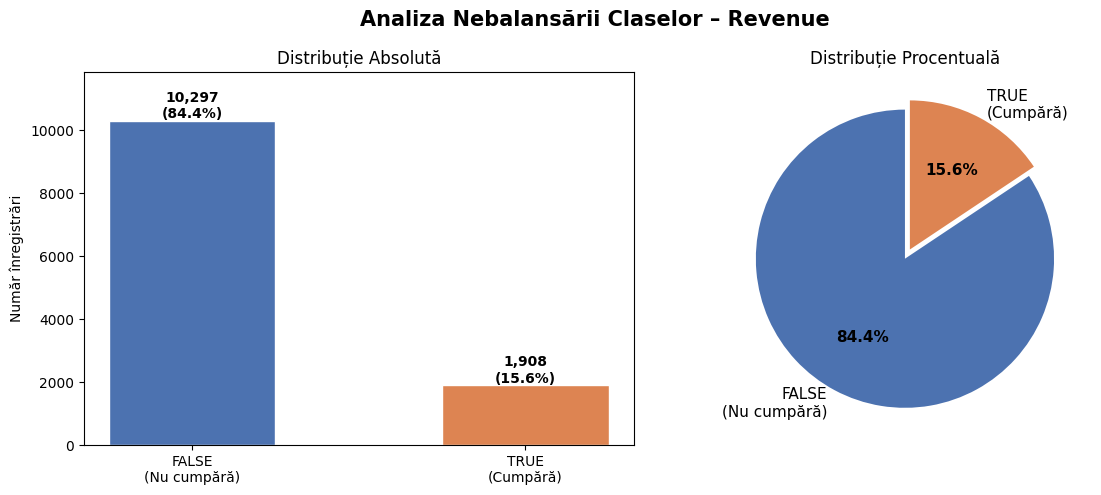

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analiza Nebalansării Claselor – Revenue', fontsize=15, fontweight='bold')
colors = ['#4C72B0', '#DD8452']

axes[0].bar(['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
            [counts[False], counts[True]],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribuție Absolută', fontsize=12)
axes[0].set_ylabel('Număr înregistrări')
for i, (v, p) in enumerate(zip([counts[False], counts[True]], [pcts[False], pcts[True]])):
    axes[0].text(i, v + 80, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylim(0, counts[False] * 1.15)

wedges, texts, autotexts = axes[1].pie(
    [counts[False], counts[True]],
    labels=['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.07),
    textprops={'fontsize': 11}
)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
axes[1].set_title('Distribuție Procentuală', fontsize=12)
 
plt.tight_layout()
plt.show()